This notebook shows how to use the METIS LMS mode in Scopesim.  The LM Spectrograph (LMS) is the integral-field unit within METIS. Strictly speaking LMS refers to the hardware subsystem and the instrument mode had better been called "IFU". The use of LMS versus IFU is somewhat inconsistent, it has grown historically and it would be hard to change it now.

In [1]:
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize

In [2]:
import scopesim as sim
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

numexpr.utils - NumExpr defaulting to 8 threads.


In addition to scopesim we need the configuration and data files that describe the atmosphere, telescope and instrument. These are downloaded from our server with

In [3]:
# Edit this path if you have a custom install directory, otherwise comment it out. [For ReadTheDocs only]
sim.link_irdb("../../../")

# If you want/need to download the instrument packages uncomment the fol
#sim.download_packages(["Armazones", "ELT", "METIS"])

The following command gives the versions of python packages that are used by Scopesim as well as of instrument packages (called IRDB packages). We ask to include the output of this command in any communication with us, in particular in bug reports.

In [4]:
sim.bug_report()

Python:
3.12.9 (main, Feb  5 2025, 01:31:18) [GCC 14.2.0]

Installed Python packages:
           anisocado: 0.4.0
         astar-utils: 0.4.0
             astropy: 6.1.7
      beautifulsoup4: 4.13.4
            docutils: 0.19
               httpx: 0.28.1
                lxml: 5.4.0
          matplotlib: 3.10.1
      more-itertools: 10.5.0
               numpy: 1.26.4
           packaging: 25.0
               pooch: 1.8.2
              pyyaml: 6.0.2
               scipy: 1.16.2
            scopesim: 0.11.2a2
       scopesim_data: could not be loaded.
  scopesim_templates: 0.6.2a0
         skycalc-ipy: 0.6.0
             synphot: 1.6.0
                tqdm: 4.67.1

Installed IRDB packages:
       HARMONI: version number not available.
         HAWKI: version number not available.
           VLT: version number not available.
        OSIRIS: version number not available.
           ELT: version number not available.
       LaPalma: version number not available.
         VISIR: version num

# Setting up the instrument

The first step is to set up the instrument in the desired configuration. There are currently two modes that use the LM spectrograph and that are of interest for simulating science observations:
- `lms`: This is the nominal lms/ifu mode that produces raw two-dimensional detector images in the way that METIS will do. To analyse these data requires a data reduction pipeline, which is not currently available. Scopesim includes a function that allows rectifying these images into a data cube with well-defined spatial and spectral dimensions as we shall demonstrate later in this notebook. This cube corresponds to a single exposure and under-samples the spatial PSF in the across-slice direction. 
- `lms_cube`: This is a convenience mode that directly simulates spectra in a data cube with square spatial pixels that properly sample the spatial PSF. Such a cube will be the result of a procedure that combines a series of dithered and rotated exposures in order to reconstruct  the PSF, which is under-sampled in individual exposures. While the simulation contains many of the noise contributions present in real data it cannot include the uncertainties related to an actual data reduction procedure and is therefore rather optimistic.

The extended or spectral IFU mode is not yet available in Scopesim.

We start by setting up a `UserCommands` object in which we specify the instrument to be used (`METIS`), the instrument mode (`lms`) as well as other parameters needed to uniquely specify the instrument setup. For the LMS, a parameter that will always have to be set is the target wavelength. In Scopesim, this can be given simply as a float (units of micrometers). 

# Using the nominal LMS mode

In [5]:
cmd = sim.UserCommands(use_instrument="METIS", set_modes=["lms"], properties={"!OBS.wavelen": 3.5})

astar.astar_utils.nested_mapping - WARNING: Overwriting non-dict [64, 64, 64, 64] with dict: {1: [32, 64, 32, 0], 2: [32, 0, 32, 64], 3: [32, 64, 32, 0], 4: [32, 0, 32, 64]}


Further parameters can be set either in the command above or separately as in

In [6]:
cmd["!OBS.interp_psf"] = False    # only scale PSF to the central wavelength

The reason for doing this will be explained below.

The `OpticalTrain` (consisting of atmosphere + telescope + instrument) is then built from the `UserCommands` object (DeprecationWarnings can be ignored):

In [7]:
metis = sim.OpticalTrain(cmd)

py.warnings - WARNING: /home/oczoske/ELT_Development/ScopeSim/scopesim/effects/metis_lms_trace_list.py:292: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release. The functionality should be moved somewhere else.
  self.meta["fov"] = self.fov_grid()

py.warnings - WARNING: /home/oczoske/ELT_Development/ScopeSim/scopesim/effects/spectral_trace_list.py:163: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release. The functionality should be moved somewhere else.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /home/oczoske/ELT_Development/ScopeSim/scopesim/effects/metis_lms_trace_list.py:61: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release. The functionality should be moved somewhere else.
  volumes = [spectral_trace.fov_grid()



An `OpticalTrain` consists of a list of `Effect` objects, which can be listed as follows:

In [8]:
metis.effects.pprint_all()

        element                      name                      class           included
------------------------ --------------------------- ------------------------- --------
               armazones          skycalc_atmosphere           SkycalcTERCurve     True
                     ELT        telescope_reflection               SurfaceList     True
                     ELT     telescope_fits_keywords         ExtraFitsKeywords     True
                   METIS          common_fore_optics               SurfaceList     True
                   METIS         adc_wheel : [False]                  ADCWheel    False
                   METIS        slit_wheel : [False]                 SlitWheel    False
                   METIS                   cold_stop         PupilTransmission     True
                   METIS        common_fits_keywords         ExtraFitsKeywords     True
                   METIS           cfo_fits_keywords         ExtraFitsKeywords     True
               METIS_LMS        

## Observation of blank sky
We start by simply observing a piece of blank sky. This way we don't have to worry about setting up an astronomical source, which we will however do shortly. IFU simulations are fairly complex and therefore need some time. Much of that time is spent on PSF convolution, which has no effect when the target fills the field of view homogeneously as blank sky does. One could turn off PSF convolution entirely by doing `metis['psf'].include = False` but one needs to be careful to turn it back on again when observing an actual source. Another way to speed things up is not to scale the PSF by wavelength - this is indeed admissable in LMS observations which cover a short wavelength range (one should not do in long-slit simulations where the PSF at the red end is nearly twice as large as at the blue end). We have already switched off PSF scaling (except to the central wavelength) above. 

In [9]:
metis.observe()

py.warnings - WARNING: /home/oczoske/ELT_Development/ScopeSim/scopesim/effects/metis_lms_trace_list.py:61: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release. The functionality should be moved somewhere else.
  volumes = [spectral_trace.fov_grid()

astar.scopesim.optics.optical_train - Observing empty field


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - Interpolating PSF onto (1, 143, 219) cube


 Spectral Traces:   0%|          | 0/28 [00:00<?, ?it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.


The result of `observe()` is an `ImagePlane` object. This is a noise-free image of the spectral layout in the detector plane. The units are photons per second (per pixel). A `readout()` is needed to put this image onto the detector array and add photon noise, dark current and other detector effects to it. We first look at the `ImagePlane`, then create a readout with exposure time 600 seconds.

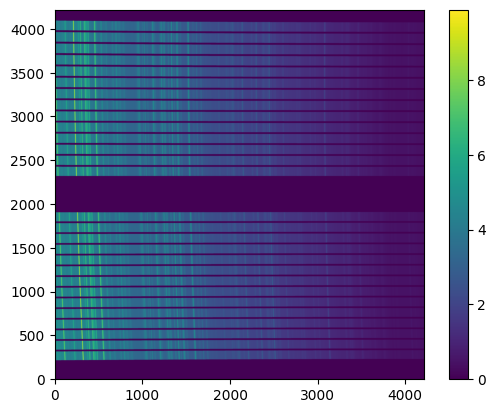

In [10]:
sky_implane = metis.image_planes[0].hdu
sky_implane.writeto("sky_implane.fits", overwrite=True)
plt.imshow(sky_implane.data, origin="lower")
plt.colorbar()

The `ImagePlane` then needs to be read out by the detectors to add all the relevant noise components. This can be repeated as often as desired, for testing different exposure times or for creating exposure sequences with the same exposure time. `readout()` also applies gain conversion, so the output of a readout is ADU. The gain for the LMS detectors is currently set at 2 electrons/ADU.

In [11]:
sky_read = metis.readout(dit=600, ndit=1)[0]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 600.000 s, NDIT = 1
astar.scopesim.effects.electronic - Total exposure time: 600.000 s
astar.scopesim.detector.detector_manager - Extracting from 4 detectors...
astar.scopesim.effects.ter_curves - Applying border [1] mapping contents:
├─1: [32, 64, 32, 0]
├─2: [32, 0, 32, 64]
├─3: [32, 64, 32, 0]
└─4: [32, 0, 32, 64]
astar.scopesim.effects.electronic.electrons - Applying gain [1] mapping contents:
├─1: 2.0
├─2: 2.0
├─3: 2.0
└─4: 2.0
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.ter_curves - Applying border [1] mapping contents:
├─1: [32, 64, 32, 0]
├─2: [32, 0, 32, 64]
├─3: [32, 64, 32, 0]
└─4: [32, 0, 32, 64]
astar.scopesim.effects.electronic.electrons - Applying gain [1] mapping contents:
├─1: 2.0
├─2: 2.0
├─3: 2.0
└─4: 2.0
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.ter_curves - Applying border 

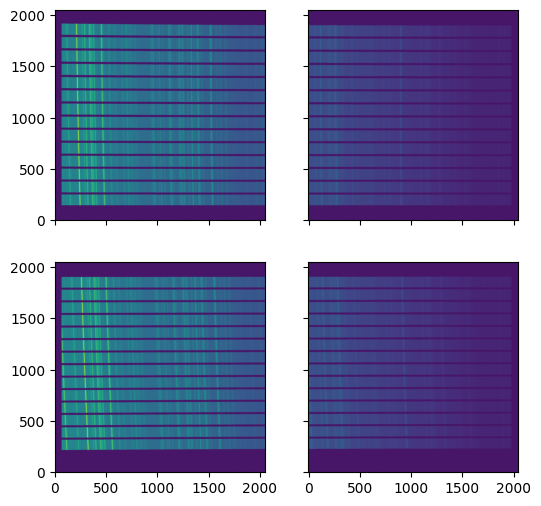

In [12]:
norm = Normalize(vmin=np.min([hdu.data for hdu in sky_read[1:]]),
                 vmax=np.max([hdu.data for hdu in sky_read[1:]]))
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))
axes[0, 0].imshow(sky_read[1].data, origin='lower', norm=norm)
axes[0, 1].imshow(sky_read[2].data, origin='lower', norm=norm)
axes[1, 0].imshow(sky_read[3].data, origin='lower', norm=norm)
axes[1, 1].imshow(sky_read[4].data, origin='lower', norm=norm)

In [13]:
# Save the sky observation for later use
sky_read.writeto("sky_lms-3.5um-600s.fits", overwrite=True)

## Observation of a source

We take the source from a fits file.

In [14]:
cubefits = "our_first_cube.fits"

In [15]:
with fits.open(cubefits) as hdul:
    print(np.any(hdul[0].data < 0))
    hdul[0].data *= -1    # This should not be done, but there seems to be a bug in Scopesim...
    src = sim.Source(cube=hdul)

False


In [16]:
metis.observe(src)

py.warnings - WARNING: /home/oczoske/ELT_Development/ScopeSim/scopesim/effects/metis_lms_trace_list.py:61: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release. The functionality should be moved somewhere else.
  volumes = [spectral_trace.fov_grid()

astar.scopesim.utils - WARNING: Calculating pixel area of header with more than 2 dimensions, assuming first two are spatial without additional checks.
astar.scopesim.optics.image_plane_utils - WARNING: imagehdu.data.ndim is 3, but wcs.naxis with key   is 2, both should be equal.
astar.scopesim.optics.image_plane_utils - WARNING: Non-linear WCS rescaled using linear procedure.


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

 Spectral Traces:   0%|          | 0/28 [00:00<?, ?it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.


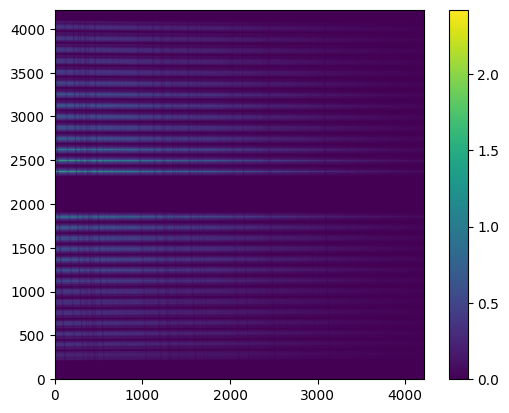

In [17]:
src_implane = metis.image_planes[0].hdu
src_implane.writeto("src_implane.fits", overwrite=True)
plt.imshow(src_implane.data - sky_implane.data, origin='lower')
plt.colorbar()

In [18]:
src_read = metis.readout(dit=600, ndit=1)[0]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 600.000 s, NDIT = 1
astar.scopesim.effects.electronic - Total exposure time: 600.000 s
astar.scopesim.detector.detector_manager - Extracting from 4 detectors...
astar.scopesim.effects.ter_curves - Applying border [1] mapping contents:
├─1: [32, 64, 32, 0]
├─2: [32, 0, 32, 64]
├─3: [32, 64, 32, 0]
└─4: [32, 0, 32, 64]
astar.scopesim.effects.electronic.electrons - Applying gain [1] mapping contents:
├─1: 2.0
├─2: 2.0
├─3: 2.0
└─4: 2.0
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.ter_curves - Applying border [1] mapping contents:
├─1: [32, 64, 32, 0]
├─2: [32, 0, 32, 64]
├─3: [32, 64, 32, 0]
└─4: [32, 0, 32, 64]
astar.scopesim.effects.electronic.electrons - Applying gain [1] mapping contents:
├─1: 2.0
├─2: 2.0
├─3: 2.0
└─4: 2.0
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.ter_curves - Applying border 

In [19]:
# If src and sky had been read out with different dit/ndit settings, sky would have to be scaled
for i in range(1, 5):
    src_read[i].data = src_read[i].data - sky_read[i].data

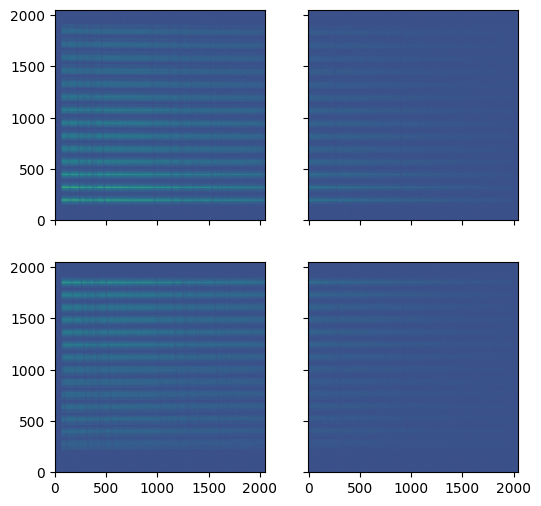

In [20]:
norm = Normalize(vmin=np.min([hdu.data for hdu in src_read[1:]]),
                 vmax=np.max([hdu.data for hdu in src_read[1:]]))
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))
axes[0, 0].imshow(src_read[1].data, origin='lower', norm=norm)
axes[0, 1].imshow(src_read[2].data, origin='lower', norm=norm)
axes[1, 0].imshow(src_read[3].data, origin='lower', norm=norm)
axes[1, 1].imshow(src_read[4].data, origin='lower', norm=norm)


In [21]:
src_read.writeto("hl_tau_lms_600s.fits", overwrite=True)

In [22]:
rectified = metis['lms_spectral_traces'].rectify_cube(src_read)

astar.scopesim.effects.metis_lms_trace_list - Computing interpolation functions
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 1
astar.scopesim.effects.spectral_trace_list_utils -    3.47 .. 3.53 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 2
astar.scopesim.effects.spectral_trace_list_utils -    3.47 .. 3.53 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 3
astar.scopesim.effects.spectral_trace_list_utils -    3.47 .. 3.53 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 4
astar.scopesim.effects.spectral_trace_list_utils -    3.47 .. 3.53 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 

We first show an image reconstruction of the cube by summing over the wavelength axis. Since the spatial pixels are rectangular we have to use the `aspect` keyword to get the correct aspect ratio. 

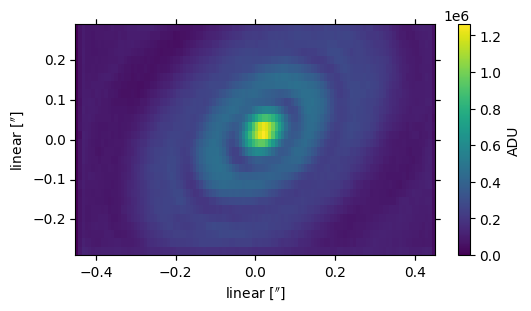

In [23]:
wcs = WCS(rectified.header)
wcs.sub(2)     # celestial part of the WCS (linear for now)
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs.sub(2)), figsize=(6, 3))
# `aspect` is needed because pixels are rectangular!
img = ax.imshow(rectified.data.sum(axis=0), origin="lower", aspect=20.7/8.2)
fig.colorbar(img, label="ADU");

The global spectrum is obtained by summing over the spatial axes. The wavelength values are obtained via the spectral part of the WCS.

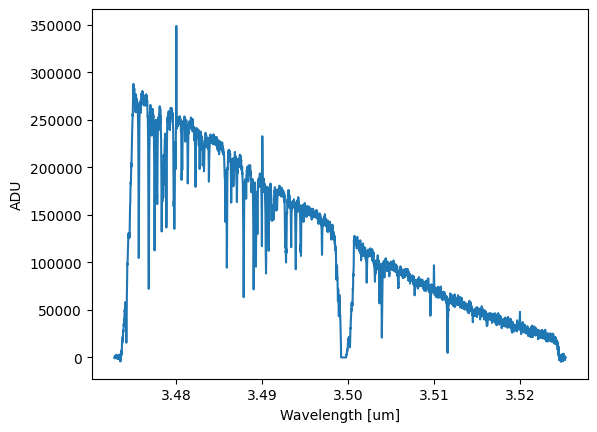

In [24]:
swcs = wcs.spectral
wavelength = swcs.all_pix2world(np.arange(rectified.data.shape[0]), 0)[0]
wavelength *= u.Unit(swcs.wcs.cunit[0]).to(u.um)
plt.plot(wavelength, rectified.data.sum(axis=(1, 2)))
plt.xlabel("Wavelength [um]")
plt.ylabel("ADU");

# Using the LMS Cube mode
The rectified spectral cube shown above has rectangular spaxels, with detector pixels of 8.2 mas along the x-direction and slices of 20.7 mas along the y-direction. When METIS is on sky a sequence of dithered and rotated exposures will be taken, which will allow reconstruction of the fully sampled field on 8.2 mas pixels in both directions. 
For convenience, Scopesim provides a mode `lms_cube` that simulates these reconstructed cubes directly. The noise levels are realistic, but the uncertainties connected to the reconstruction procedure are not.

In [25]:
cmd = sim.UserCommands(use_instrument="METIS", set_modes=['lms_cube'], properties={"!OBS.wavelen": 3.5})

astar.scopesim.commands.user_commands - Mode 'lms_cube' is still in experimental stage, results may not be representative of physical instrument.


In [26]:
cmd["!SIM.spectral.spectral_bin_width"] = 1e-5

In [27]:
metis = sim.OpticalTrain(cmd)

In [ ]:
metis.observe(src)

astar.scopesim.utils - WARNING: Calculating pixel area of header with more than 2 dimensions, assuming first two are spatial without additional checks.
astar.scopesim.optics.image_plane_utils - WARNING: imagehdu.data.ndim is 3, but wcs.naxis with key   is 2, both should be equal.
astar.scopesim.optics.image_plane_utils - WARNING: Non-linear WCS rescaled using linear procedure.


 FOV effects:   0%|          | 0/3 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - Interpolating PSF onto (1, 219, 219) cube


In [ ]:
metis.image_planes[0].data.shape

In [ ]:
src_cube = metis.readout(dit=600, ndit=1)[0]

`readout()` results in a 3D FITS cube with a linear wavelength scale and two spatial dimensions. We will look at the spatial and spectral dimensions, respectively summed over the remaining dimensions.

In [ ]:
wcs = WCS(src_cube)
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs.sub(2)))
img = ax.imshow(src_cube[1].data.sum(axis=0), origin='lower')
fig.colorbar(img, label="ADU");

In [ ]:
swcs = wcs.spectral
wavelength = swcs.all_pix2world(np.arange(src_cube[1].data.shape[0]), 0)[0]
wavelength *= u.Unit(swcs.wcs.cunit[0]).to(u.um)
plt.plot(wavelength, src_cube[1].data.sum(axis=(1, 2)))
plt.xlabel("Wavelength [um]")
plt.ylabel("ADU");

In [ ]:
metis.observe()

In [ ]:
sky_cube = metis.readout(dit=600, ndit=1)[0]

In [ ]:
plt.plot((src_cube[1].data - sky_cube[1].data).sum(axis=(1, 2)), label="Cube mode")
plt.plot(wavelength, rectified.data.sum(axis=(1, 2)), label="Nominal mode")
plt.legend()
plt.xlabel("Wavelength [um]")
plt.ylabel("ADU");